## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.neighbors import NearestNeighbors

2024-09-30 16:38:35.817983: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-30 16:38:35.818128: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-30 16:38:35.962098: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Load Image Data

In [2]:
# Define the path to your images directory
image_dir = '/kaggle/input/fashion-product-images-small/images/'

# List all image files
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
    
# Create a DataFrame with image paths
image_df = pd.DataFrame({'filename': image_files})
image_df['filepath'] = image_df['filename'].apply(lambda x: os.path.join(image_dir, x))

print(f"Total images found: {len(image_df)}")


Total images found: 44441


In [3]:
image_df.head()

,filename,filepath
0,31973.jpg,/kaggle/input/fashion-product-images-small/ima...
1,30778.jpg,/kaggle/input/fashion-product-images-small/ima...
2,19812.jpg,/kaggle/input/fashion-product-images-small/ima...
3,22735.jpg,/kaggle/input/fashion-product-images-small/ima...
4,38246.jpg,/kaggle/input/fashion-product-images-small/ima...


## Load and Preprocess Images

Define a function to load and preprocess the images:

In [4]:
def load_and_preprocess_image(filepath, target_size=(224, 224)):
    # Load image
    image = load_img(filepath, target_size=target_size)
    # Convert image to array
    image = img_to_array(image)
    # Expand dimensions to match model input shape
    image = np.expand_dims(image, axis=0)
    # Preprocess image for VGG16
    image = preprocess_input(image)
    return image


## Extract Features Using a Pretrained Model (VGG16)

Use the VGG16 model pre-trained on ImageNet to extract features from the images:

In [5]:
# Load VGG16 model pre-trained on ImageNet
base_model = VGG16(weights='imagenet')
# Remove the top layer to use VGG16 as a feature extractor
model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc1').output)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


In [6]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm  # For displaying the progress bar

# Function to extract features from an image file using VGG16 model
def extract_features_threaded(model, filepath):
    try:
        image = load_and_preprocess_image(filepath)  # Load and preprocess the image
        features = model.predict(image, verbose=False)  # Extract features
        return features.flatten()  # Return flattened feature array
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        return None  # Return None if an error occurs

# Wrapper function to process images in parallel
def extract_features_parallel(model, filepaths, max_workers=15):
    features_list = []  # List to store extracted features
    # Use ThreadPoolExecutor for parallel processing
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Submit tasks to the executor and map them to their file paths
        future_to_filepath = {executor.submit(extract_features_threaded, model, path): path for path in filepaths}
        
        # Use tqdm to display the progress bar as tasks complete
        for future in tqdm(as_completed(future_to_filepath), total=len(filepaths), desc="Extracting Features"):
            result = future.result()  # Get the result from each completed future
            if result is not None:  # Only add non-None results to the features list
                features_list.append(result)

    return np.array(features_list)  # Return the compiled feature matrix

# List of filepaths from the DataFrame
filepaths = image_df['filepath'].tolist()

In [7]:
# Extract features using multi-threading and display progress with tqdm
# feature_matrix = extract_features_parallel(model, filepaths, max_workers=8)
feature_matrix = np.load("/kaggle/input/fashon-recomendation-sytem-dataset/Images_fetures_VGG.npy")

# Check the shape of the feature matrix
print(f"Feature matrix shape: {feature_matrix.shape}")

# Update the DataFrame with extracted features
image_df['features'] = list(feature_matrix)

Feature matrix shape: (44441, 4096)


In [8]:
# np.save('Images_fetures_VGG1gfvhg.npy', feature_matrix)  

## Build a Recommendation System Using Nearest Neighbors

Use the extracted features to build a recommendation system with Nearest Neighbors:

In [9]:
# Initialize Nearest Neighbors model
# nn_model = NearestNeighbors(n_neighbors=5, metric='cosine')
nn_model = NearestNeighbors(n_neighbors=6, algorithm='brute',metric='euclidean')

# Fit model on the feature matrix
nn_model.fit(feature_matrix)

# Function to get recommendations
def get_recommendations(image_index, num_recommendations=5):
    distances, indices = nn_model.kneighbors([feature_matrix[image_index]], n_neighbors=num_recommendations)
    return indices.flatten(), distances.flatten()

## Display Recommendations

Let’s display the recommended images visually, along with their similarity scores:

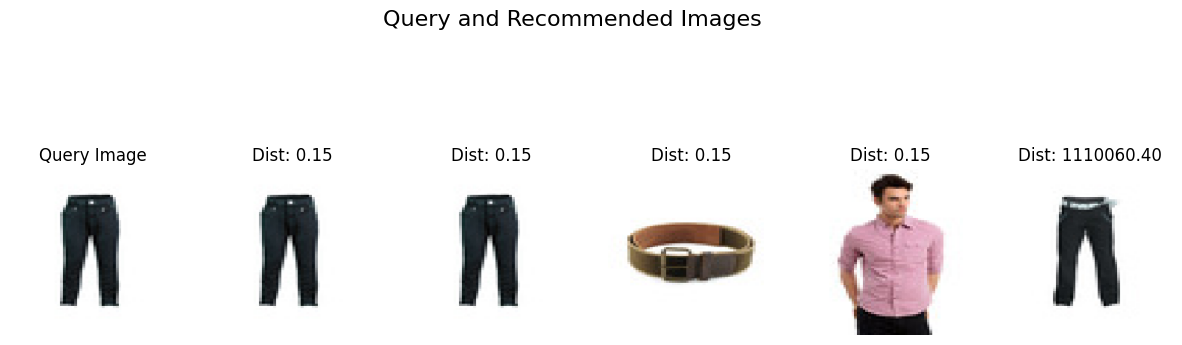

In [13]:
def display_recommendations_with_query(image_index, num_recommendations=5):
    """
    Display the query image along with its recommended similar images.

    :param image_index: Index of the query image in the DataFrame.
    :param num_recommendations: Number of similar images to display.
    """
    # Get the indices and distances of the recommended images
    indices, distances = get_recommendations(image_index, num_recommendations)

    # Create a figure to display the query and recommended images
    plt.figure(figsize=(15, 5))

    # Display the query image (the one we are finding similar images for)
    query_img_path = image_df.iloc[image_index]['filepath']
    query_img = load_img(query_img_path, target_size=(224, 224))
    plt.subplot(1, num_recommendations + 1, 1)  # Adding 1 to include the query image
    plt.imshow(query_img)
    plt.title("Query Image")
    plt.axis('off')

    # Display the recommended images
    for i, idx in enumerate(indices):
        img_path = image_df.iloc[idx]['filepath']
        img = load_img(img_path, target_size=(224, 224))
        plt.subplot(1, num_recommendations + 1, i + 2)  # Offset by 2 to accommodate the query image
        plt.imshow(img)
        plt.title(f"Dist: {distances[i]:.2f}")
        plt.axis('off')

    # Display the plot
    plt.suptitle("Query and Recommended Images", fontsize=16)
    plt.show()

# Example usage: Display recommendations for the first image in the dataset
display_recommendations_with_query(100, num_recommendations=5)


## Display a Loss-like Chart (Similarity Distance Plot)

This step involves plotting the similarity distance of recommended images, mimicking a "loss" or "accuracy" chart:

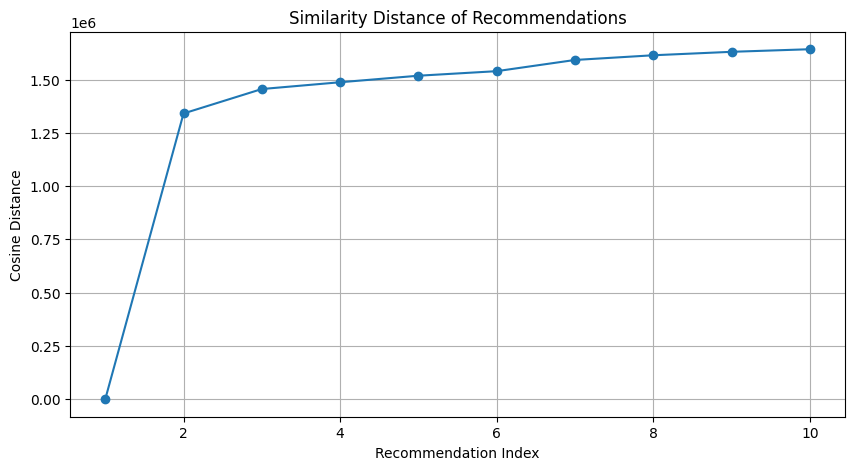

In [11]:
def plot_similarity_distances(image_index, num_recommendations=10):
    indices, distances = get_recommendations(image_index, num_recommendations)
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_recommendations + 1), distances, marker='o')
    plt.xlabel('Recommendation Index')
    plt.ylabel('Cosine Distance')
    plt.title('Similarity Distance of Recommendations')
    plt.grid()
    plt.show()

# Plot similarity distances for the first image
plot_similarity_distances(0)


### Summary

    - Load Images: Load images from the directory and create a DataFrame to track their paths.
    - Preprocess Images: Resize and preprocess images using a utility function.
    - Feature Extraction: Use a pre-trained VGG16 model to extract image features.
    - Nearest Neighbors Model: Fit a Nearest Neighbors model on the extracted features.
    - Get Recommendations: Retrieve similar items using the recommendation function.
    - Recommendation Display: Visually compares recommended items to assess the model's effectiveness.
    - Similarity Distance Plot: Provides insight into how similar the recommended images are.